In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv("batch_results.csv")

saved.


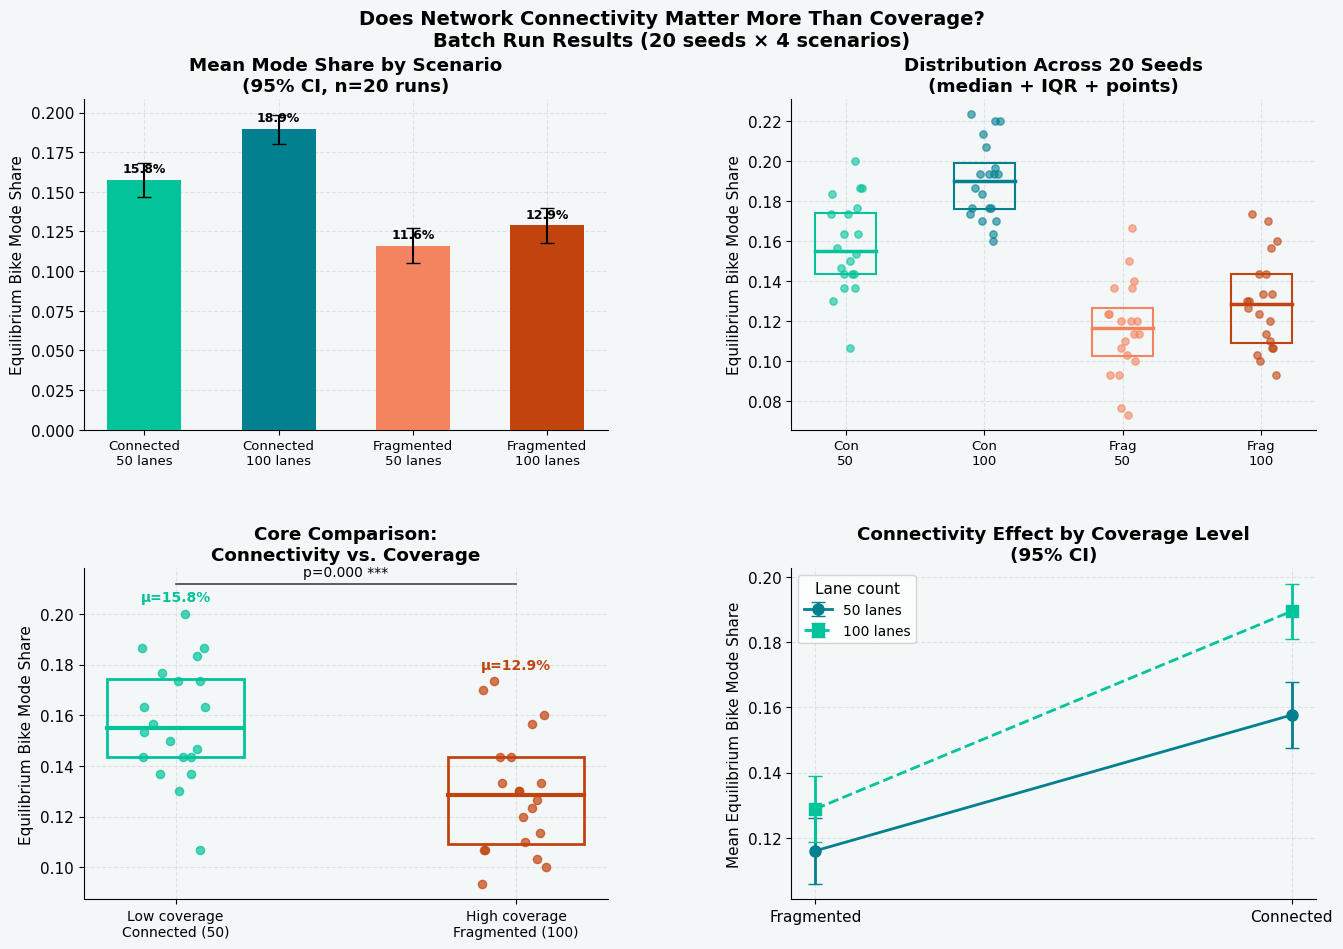

In [ ]:
#  Styling
COLORS = {
    ("connected", 50): "#02C39A",
    ("connected", 100): "#028090",
    ("fragmented", 50): "#F4845F",
    ("fragmented", 100): "#C1440E",
}
LABELS = {
    ("connected", 50): "Connected, 50 lanes",
    ("connected", 100): "Connected, 100 lanes",
    ("fragmented", 50): "Fragmented, 50 lanes",
    ("fragmented", 100): "Fragmented, 100 lanes",
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor("#F4F7F8")

gs = fig.add_gridspec(
    2, 2, hspace=0.42, wspace=0.35, left=0.08, right=0.96, top=0.88, bottom=0.08
)

# 1. Bar chart: mean mode share by scenario
ax1 = fig.add_subplot(gs[0, 0])
groups = [
    ("connected", 50),
    ("connected", 100),
    ("fragmented", 50),
    ("fragmented", 100),
]
means, cis, colors, labels = [], [], [], []

for key in groups:
    conn, lanes = key
    subset = df[(df["connectivity"] == conn) & (df["n_lanes"] == lanes)][
        "cycling_mode_share"
    ]
    mean = subset.mean()
    ci = stats.t.interval(0.95, len(subset) - 1, loc=mean, scale=stats.sem(subset))
    means.append(mean)
    cis.append((mean - ci[0], ci[1] - mean))
    colors.append(COLORS[key])
    labels.append(LABELS[key])

x = np.arange(len(groups))
bars = ax1.bar(
    x,
    means,
    color=colors,
    width=0.55,
    zorder=3,
    yerr=np.array(cis).T,
    capsize=5,
    error_kw={"linewidth": 1.5, "color": "#444"},
)

ax1.set_xticks(x)
ax1.set_xticklabels(
    [
        "Connected\n50 lanes",
        "Connected\n100 lanes",
        "Fragmented\n50 lanes",
        "Fragmented\n100 lanes",
    ],
    fontsize=9.5,
)
ax1.set_ylabel("Equilibrium Bike Mode Share")
ax1.set_title("Mean Mode Share by Scenario\n(95% CI, n=20 runs)", fontweight="bold")
ax1.set_facecolor("#F4F7F8")
for bar, mean in zip(bars, means):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{mean:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

# 2. Strip + box: distribution of mode shares
ax2 = fig.add_subplot(gs[0, 1])
for i, key in enumerate(groups):
    conn, lanes = key
    subset = df[(df["connectivity"] == conn) & (df["n_lanes"] == lanes)][
        "cycling_mode_share"
    ]
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(subset))
    ax2.scatter(
        np.full(len(subset), i) + jitter,
        subset,
        color=COLORS[key],
        alpha=0.6,
        s=28,
        zorder=4,
    )
    # box
    q1, median, q3 = np.percentile(subset, [25, 50, 75])
    ax2.plot(
        [i - 0.22, i + 0.22],
        [median, median],
        color=COLORS[key],
        linewidth=2.5,
        zorder=5,
    )
    ax2.add_patch(
        plt.Rectangle(
            (i - 0.22, q1),
            0.44,
            q3 - q1,
            fill=False,
            edgecolor=COLORS[key],
            linewidth=1.5,
            zorder=4,
        )
    )

ax2.set_xticks(range(4))
ax2.set_xticklabels(["Con\n50", "Con\n100", "Frag\n50", "Frag\n100"], fontsize=9.5)
ax2.set_ylabel("Equilibrium Bike Mode Share")
ax2.set_title(
    "Distribution Across 20 Seeds\n(median + IQR + points)", fontweight="bold"
)
ax2.set_facecolor("#F4F7F8")

# 3. Core comparison: low connected vs high fragmented
ax3 = fig.add_subplot(gs[1, 0])
lc = df[(df["connectivity"] == "connected") & (df["n_lanes"] == 50)][
    "cycling_mode_share"
]
hf = df[(df["connectivity"] == "fragmented") & (df["n_lanes"] == 100)][
    "cycling_mode_share"
]

# t-test
t_stat, p_val = stats.ttest_ind(lc, hf)

comp_data = [lc.values, hf.values]
comp_colors = [COLORS[("connected", 50)], COLORS[("fragmented", 100)]]
comp_labels = ["Low coverage\nConnected (50)", "High coverage\nFragmented (100)"]

for i, (data, color) in enumerate(zip(comp_data, comp_colors)):
    jitter = np.random.default_rng(0).uniform(-0.1, 0.1, len(data))
    ax3.scatter(
        np.full(len(data), i) + jitter, data, color=color, alpha=0.7, s=35, zorder=4
    )
    ax3.plot(
        [i - 0.2, i + 0.2],
        [np.median(data), np.median(data)],
        color=color,
        linewidth=3,
        zorder=5,
    )
    q1, q3 = np.percentile(data, [25, 75])
    ax3.add_patch(
        plt.Rectangle(
            (i - 0.2, q1),
            0.4,
            q3 - q1,
            fill=False,
            edgecolor=color,
            linewidth=2,
            zorder=4,
        )
    )
    ax3.text(
        i,
        max(data) + 0.005,
        f"μ={np.mean(data):.1%}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=color,
    )

sig = (
    "***"
    if p_val < 0.001
    else "**"
    if p_val < 0.01
    else "*"
    if p_val < 0.05
    else "n.s."
)
y_bar = max(lc.max(), hf.max()) + 0.012
ax3.plot([0, 1], [y_bar, y_bar], color="#444", linewidth=1.2)
ax3.text(0.5, y_bar + 0.003, f"p={p_val:.3f} {sig}", ha="center", fontsize=10)

ax3.set_xticks([0, 1])
ax3.set_xticklabels(comp_labels, fontsize=10)
ax3.set_ylabel("Equilibrium Bike Mode Share")
ax3.set_title("Core Comparison:\nConnectivity vs. Coverage", fontweight="bold")
ax3.set_facecolor("#F4F7F8")

# 4. Connectivity effect at each coverage level
ax4 = fig.add_subplot(gs[1, 1])
for lanes, ls, marker in [(50, "-", "o"), (100, "--", "s")]:
    conn_mean = df[(df["connectivity"] == "connected") & (df["n_lanes"] == lanes)][
        "cycling_mode_share"
    ].mean()
    frag_mean = df[(df["connectivity"] == "fragmented") & (df["n_lanes"] == lanes)][
        "cycling_mode_share"
    ].mean()
    conn_ci = stats.sem(
        df[(df["connectivity"] == "connected") & (df["n_lanes"] == lanes)][
            "cycling_mode_share"
        ]
    )
    frag_ci = stats.sem(
        df[(df["connectivity"] == "fragmented") & (df["n_lanes"] == lanes)][
            "cycling_mode_share"
        ]
    )

    ax4.errorbar(
        [0, 1],
        [frag_mean, conn_mean],
        yerr=[frag_ci * 1.96, conn_ci * 1.96],
        linestyle=ls,
        marker=marker,
        markersize=8,
        linewidth=2,
        color="#028090" if lanes == 50 else "#02C39A",
        label=f"{lanes} lanes",
        capsize=5,
    )

ax4.set_xticks([0, 1])
ax4.set_xticklabels(["Fragmented", "Connected"], fontsize=11)
ax4.set_ylabel("Mean Equilibrium Bike Mode Share")
ax4.set_title("Connectivity Effect by Coverage Level\n(95% CI)", fontweight="bold")
ax4.legend(title="Lane count", fontsize=10)
ax4.set_facecolor("#F4F7F8")

# Title
fig.suptitle(
    "Does Network Connectivity Matter More Than Coverage?\nBatch Run Results (20 seeds × 4 scenarios)",
    fontsize=14,
    fontweight="bold",
    y=0.97,
)

plt.savefig(
    "batch_results.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#F4F7F8",
)
print("saved.")